# 低評価予測モデル

価格・送料・配送遅延日数からレビュー1～2点を予測する。Trainで学習し、Validationでしきい値を決め、Testで最終評価する。

共通の集計・作図関数は`../src/`に置き、Notebookには分析の問い、対象データ、結果の読み方を残す。


## データと目的変数


In [ ]:
from pathlib import Path
import sys
PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src").is_dir() and (path / "notebooks").is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from src.project_paths import DATA_DIR
from src.model_metrics import (
    threshold_metrics, threshold_table, final_classification_metrics,
)

df_review_order = pd.read_csv(DATA_DIR / "review_order_summary.csv")
df_delivery = pd.read_csv(DATA_DIR / "delivery_delay_review_summary.csv")
df_merge = pd.merge(
    df_review_order,
    df_delivery[["order_id", "delivery_delay_days"]],
    on="order_id", how="inner",
)
print(df_merge.shape)
print(df_merge.head())
print(df_merge.isna().sum())

In [2]:
# 低評価の定義

df_merge["low_review"] = (
    df_merge["review_score"] <= 2
).astype(int)

In [3]:
print(
    df_merge["low_review"]
    .value_counts()
    .sort_index()
)

print(
    df_merge["low_review"]
    .value_counts(normalize=True)
    .sort_index()
)

low_review
0    83590
1    12240
Name: count, dtype: int64
low_review
0    0.872274
1    0.127726
Name: proportion, dtype: float64


In [4]:
features = [
    "total_price",
    "total_freight",
    "delivery_delay_days"
]

print(df_merge[features].describe())

        total_price  total_freight  delivery_delay_days
count  95830.000000   95830.000000         95830.000000
mean     136.798400      22.762521           -11.914067
std      207.782774      21.522100            10.113511
min        0.850000       0.000000          -147.000000
25%       45.900000      13.840000           -17.000000
50%       86.250000      17.160000           -12.000000
75%      149.900000      23.990000            -7.000000
max    13440.000000    1794.960000           188.000000


## Train・Validation・Testに分割


In [5]:
from sklearn.model_selection import train_test_split

X = df_merge[features]
y = df_merge["low_review"]

# まずTrainを60%、残りを40%に分ける
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

# 残り40%をValidationとTestに半分ずつ分ける
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

for name, y_part in [
    ("Train", y_train),
    ("Validation", y_validation),
    ("Test", y_test)
]:
    print(
        f"{name}: {len(y_part):,}件, "
        f"低評価率 = {y_part.mean():.2%}"
    )


Train: 57,498件, 低評価率 = 12.77%
Validation: 19,166件, 低評価率 = 12.77%
Test: 19,166件, 低評価率 = 12.77%


In [6]:
# 変数スケールがかなり違うので標準化

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

In [7]:
# ロジスティック回帰モデルを適用

from sklearn.linear_model import LogisticRegression

model_LogisticRegression = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model_LogisticRegression.fit(X_train_scaled, y_train)

print(model_LogisticRegression)
print("classed:", model_LogisticRegression.classes_)
print("coefficients:", model_LogisticRegression.coef_)
print("intercept:", model_LogisticRegression.intercept_)

LogisticRegression(max_iter=1000, random_state=42)
classed: [0 1]
coefficients: [[0.01350116 0.23509651 0.76751678]]
intercept: [-2.10271234]


In [8]:
# オッズ比、相関係数を出力

odds_ratios = np.exp(
    model_LogisticRegression.coef_[0]
)

coef_summary = pd.DataFrame({
    "feature": features,
    "coefficient": model_LogisticRegression.coef_[0],
    "odds_ratio": odds_ratios
})

coef_summary

,feature,coefficient,odds_ratio
0,total_price,0.013501,1.013593
1,total_freight,0.235097,1.265031
2,delivery_delay_days,0.767517,2.154410


In [9]:
# Validationデータセットを用いて予測と予測確率を出力

y_pred = model_LogisticRegression.predict(
    X_validation_scaled
)

y_prob = model_LogisticRegression.predict_proba(
    X_validation_scaled
)

print("予測結果:")
print(y_pred[:20])

print("\n予測確率:")
print(y_prob[:5])

予測結果:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

予測確率:
[[0.74045538 0.25954462]
 [0.90644268 0.09355732]
 [0.92173977 0.07826023]
 [0.81800967 0.18199033]
 [0.92013237 0.07986763]]


In [10]:
# 混合同列 (Confusion Matrix) を作成

from sklearn.metrics import confusion_matrix

Confusion_matrix = confusion_matrix(
    y_validation,
    y_pred
)

print(Confusion_matrix)

[[16651    67]
 [ 2271   177]]


In [11]:
# 精度、Ｆ１スコア、適合率、再現率を計算

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

accuracy = accuracy_score(y_validation, y_pred)
precision = precision_score(y_validation, y_pred)
recall = recall_score(y_validation, y_pred)
f1 = f1_score(y_validation, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8780
Precision: 0.7254
Recall   : 0.0723
F1-score : 0.1315


In [12]:
# 予測が１（低評価）のデータを確認

y_prob_low = y_prob[:, 1]

print(y_prob_low[:20])

print("最小値:", y_prob_low.min())
print("最大値:", y_prob_low.max())
print("中央値:", y_prob_low.median() if hasattr(y_prob_low, "median") else np.median(y_prob_low))

[0.25954462 0.09355732 0.07826023 0.18199033 0.07986763 0.06433013
 0.0327268  0.11675021 0.11249972 0.05717629 0.12297685 0.09922972
 0.1447687  0.08221878 0.13071051 0.09271309 0.13351063 0.06530391
 0.15464389 0.05719967]
最小値: 4.043850951521716e-06
最大値: 0.9999844585288352
中央値: 0.10521614350997324


０に近い最小の値もあれば、100に近い最大の値もある。しかし、中央値を見ると10%なので、50%のしきい値設定を調整する必要がある。

In [13]:
# ROC-AUCを計算

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_validation,
    y_prob_low
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.6717


In [14]:
# ROC曲線のしきい値（Thresholds）を変化させていった時の、偽陽性率、真陽性率を表示

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_validation,
    y_prob_low
)

print("FPR:", fpr[:10])
print("TPR:", tpr[:10])
print("Thresholds:", thresholds[:10])



FPR: [0.00000000e+00 5.98157674e-05 1.79447302e-04 1.79447302e-04
 4.18710372e-04 4.18710372e-04 5.38341907e-04 5.38341907e-04
 5.98157674e-04 5.98157674e-04]
TPR: [0.         0.         0.         0.0004085  0.0004085  0.00163399
 0.00163399 0.00204248 0.00204248 0.00326797]
Thresholds: [       inf 0.99998446 0.99987069 0.99922632 0.98983032 0.95998049
 0.95554795 0.95537094 0.94958835 0.94033155]


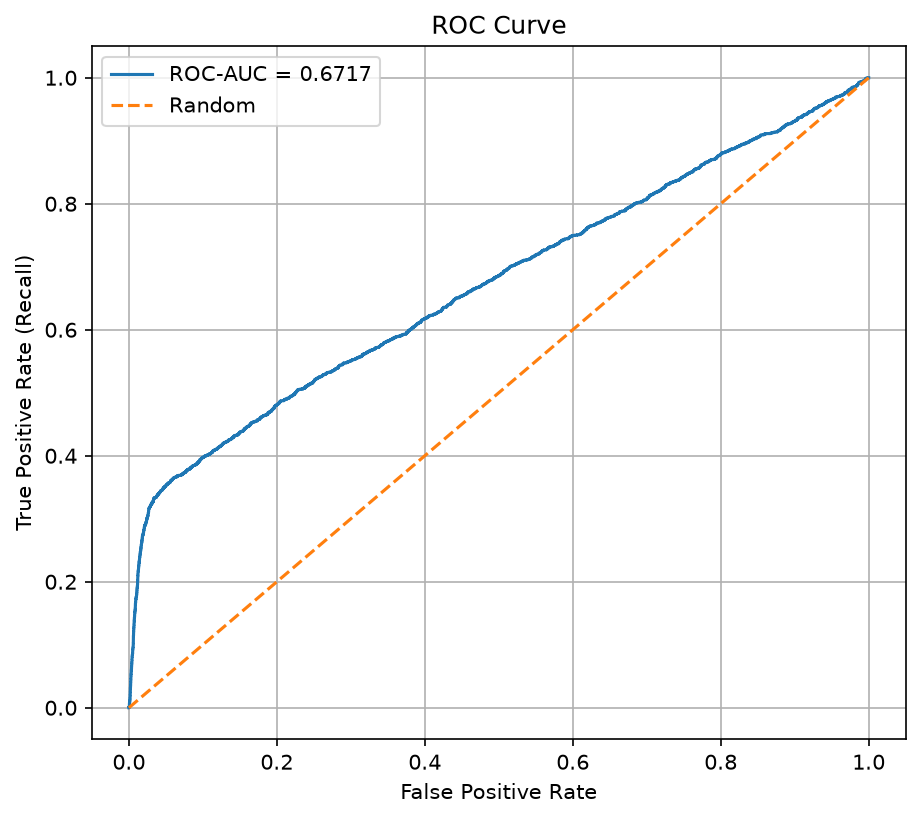

In [15]:
# ROC曲線を描画

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# 0.30の例で、しきい値を下げた時の指標を確認する。
threshold = 0.30
y_pred_30 = (y_prob_low >= threshold).astype(int)
print(y_pred_30[:20])
metrics_30 = threshold_metrics(y_validation, y_prob_low, threshold)
for name in ["accuracy", "precision", "recall", "f1"]:
    print(f"{name}: {metrics_30[name]:.4f}")

## Validationでしきい値を選ぶ


In [ ]:
# Validation上でのみF1が大きいしきい値を探す。
threshold_results = threshold_table(y_validation, y_prob_low)
best_threshold = float(threshold_results.loc[
    threshold_results["f1"].idxmax(), "threshold"
])
print(f"ValidationでF1が最大のしきい値: {best_threshold:.2f}")
threshold_results.sort_values("f1", ascending=False).head(10)

しきい値が24%のときにＦ１スコアが最大。

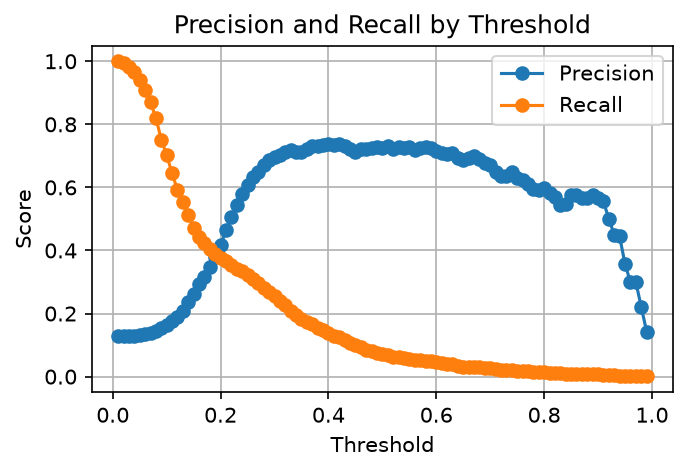

In [18]:
# 適合率と再現率がしきい値によってどう変化するかを確認

plt.figure(figsize=(5, 3))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall by Threshold")
plt.legend()
plt.grid()
plt.show()

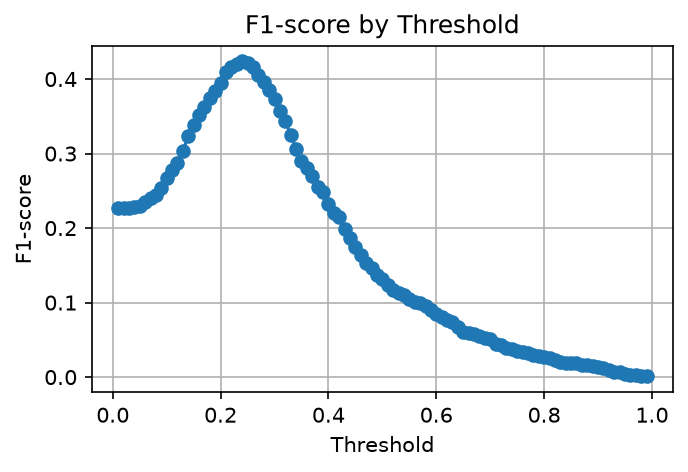

In [19]:
# F1スコアのしきい値による変化を確認

plt.figure(figsize=(5, 3))

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o"
)

plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score by Threshold")
plt.grid()
plt.show()

In [20]:
# 適合率、再現率の変化を計算

from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(
    y_validation,
    y_prob_low
)

print("Precision:", precision[:10])
print("Recall:", recall[:10])
print("Thresholds:", pr_thresholds[:10])

Precision: [0.12772618 0.12773285 0.12773951 0.12774618 0.12775284 0.12775951
 0.12776618 0.12777285 0.12777952 0.12778619]
Recall: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Thresholds: [4.04385095e-06 7.28449970e-06 1.00486973e-05 6.82004239e-05
 5.69837488e-04 7.78987408e-04 8.05658498e-04 1.09627447e-03
 1.33366152e-03 1.70270926e-03]


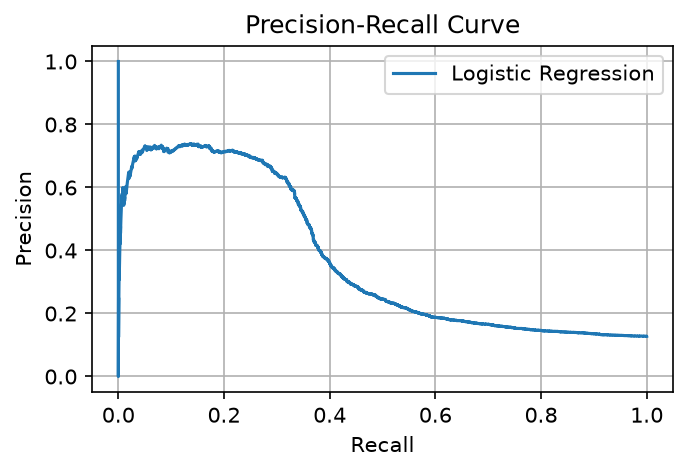

In [21]:
# 適合率、再現率の変化を描画

plt.figure(figsize=(5, 3))

plt.plot(
    recall,
    precision,
    label="Logistic Regression"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

plt.show()

## Testで最終評価

Test結果を見てしきい値を選び直さない。


In [ ]:
# Validationで選んだbest_thresholdを固定して、Testで一度だけ最終評価する。
y_test_prob_low = model_LogisticRegression.predict_proba(X_test_scaled)[:, 1]
test_metrics = final_classification_metrics(y_test, y_test_prob_low, best_threshold)
print("しきい値:", best_threshold)
print("混同行列:")
print(test_metrics["confusion_matrix"])
for name in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"{name}: {test_metrics[name]:.4f}")